## Solving 2x2 Sudoku with Grover's Algorithm

This notebook demonstrates how to solve a 2x2 Sudoku puzzle using Grover's quantum search algorithm. The problem is encoded into quantum states, and the oracle marks the correct solution by applying a phase shift. Grover's diffusion operator then amplifies the amplitude of the marked state, making it highly probable to measure the solution.

The 2x2 Sudoku puzzle can be represented by 4 qubits, where each qubit represents a cell in the 2x2 grid. The goal is to fill the grid with numbers such that each row and each column contains unique numbers (e.g., 0 and 1).

Here's how the quantum circuit is constructed:
- `sudoku_oracle`: This function encodes the rules of the 2x2 Sudoku puzzle. It applies a phase kickback to valid solutions.
- `diffusion`: This function implements Grover's diffusion operator, which amplifies the probability of measuring the correct solution.

The circuit is run for a certain number of Grover iterations (typically square root of total states) to enhance the probability of finding the correct solution.

The output shows a histogram of measurement counts, where the most frequent result corresponds to the solution of the Sudoku puzzle.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Kraus

In [ ]:
def sudoku_oracle(qc, data, anc, phase):
    # a1 = NOT(q1)
    qc.x(anc[0])
    qc.cx(data[0], anc[0])

    # a2 = q1 XOR q2
    qc.cx(data[0], anc[1])
    qc.cx(data[1], anc[1])

    # a3 = q3 XOR q4
    qc.cx(data[2], anc[2])
    qc.cx(data[3], anc[2])

    # a4 = q1 XOR q3
    qc.cx(data[0], anc[3])
    qc.cx(data[2], anc[3])

    # a5 = q2 XOR q4
    qc.cx(data[1], anc[4])
    qc.cx(data[3], anc[4])

    # Mark valid state by phase kickback
    qc.mcx([anc[0], anc[1], anc[2], anc[3], anc[4]], phase[0])

    # Uncompute ancillas
    qc.cx(data[3], anc[4])
    qc.cx(data[1], anc[4])

    qc.cx(data[2], anc[3])
    qc.cx(data[0], anc[3])

    qc.cx(data[3], anc[2])
    qc.cx(data[2], anc[2])

    qc.cx(data[1], anc[1])
    qc.cx(data[0], anc[1])

    qc.cx(data[0], anc[0])
    qc.x(anc[0])


def diffusion(qc, data):
    qc.h(data)
    qc.x(data)

    qc.h(data[3])
    qc.mcx([data[0], data[1], data[2]], data[3])
    qc.h(data[3])

    qc.x(data)
    qc.h(data)

def grover_iterate(qc, data, anc, phase):
    sudoku_oracle(qc, data, anc, phase)
    diffusion(qc, data)

# Registers
data = QuantumRegister(4, "q")
anc = QuantumRegister(5, "a")
phase = QuantumRegister(1, "p")
cl = ClassicalRegister(4, "c")

# Circuit
qc = QuantumCircuit(data, anc, phase, cl)

# Prepare phase ancilla in |->
qc.x(phase[0])
qc.h(phase[0])

# Put all 16 candidates into equal superposition
qc.h(data)


# Grover iterations
for _ in range(3):
    grover_iterate(qc, data, anc, phase)

# Measure
qc.measure(data, cl)

# Simulate
sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=4096).result()
counts = result.get_counts()

print(counts)

{'0010': 7, '0000': 10, '1000': 10, '0110': 3949, '1101': 12, '1100': 6, '0001': 8, '1111': 3, '1110': 12, '1001': 15, '0101': 10, '1010': 11, '0011': 8, '0111': 14, '1011': 8, '0100': 13}


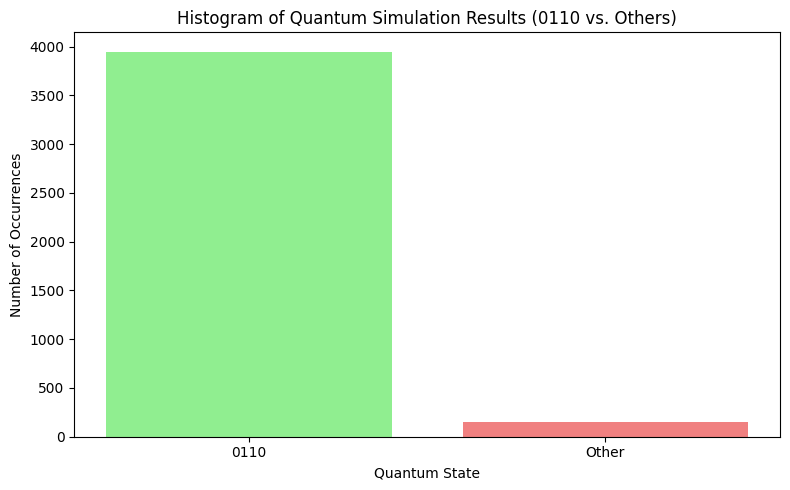

In [ ]:
import matplotlib.pyplot as plt

# Extract the count for '0110'
count_0110 = counts.get('0110', 0)

# Calculate the sum of all other counts
other_counts_sum = sum(v for k, v in counts.items() if k != '0110')

# Create a new dictionary for the modified histogram
modified_counts = {'0110': count_0110, 'Other': other_counts_sum}

# Create a bar chart for the histogram
plt.figure(figsize=(8, 5))
plt.bar(modified_counts.keys(), modified_counts.values(), color=['lightgreen', 'lightcoral'])
plt.xlabel('Quantum State')
plt.ylabel('Number of Occurrences')
plt.title('Histogram of Quantum Simulation Results (0110 vs. Others)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Grover’s Algorithm under Iterate-Level Noise

We study how noise affects Grover’s algorithm by applying a global depolarizing channel once per Grover iterate:
$$
G_p = N_p \circ G,
\quad
N_p(\rho) = (1-p)\rho + p \frac{I}{16}.
$$

We analyze:
- How the success probability of finding the target state varies with noise strength ($p$).
- Amplification curves, showing how the success probability evolves with the number of Grover iterations ($T$) across different noise levels.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Kraus


# 1. Global depolarizing channel

def global_depolarizing_instruction(p, n_qubits=4):
    if p == 0.0:
        return None

    d = 2 ** n_qubits
    lam = p * (d ** 2) / (d ** 2 - 1)

    I = np.array([[1, 0], [0, 1]], dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    pauli_single = {"I": I, "X": X, "Y": Y, "Z": Z}

    kraus_ops = [np.sqrt(1.0 - lam) * np.eye(d, dtype=complex)]
    coeff = np.sqrt(lam / (4 ** n_qubits - 1))

    for word in product("IXYZ", repeat=n_qubits):
        if all(ch == "I" for ch in word):
            continue
        P = pauli_single[word[0]]
        for ch in word[1:]:
            P = np.kron(P, pauli_single[ch])
        kraus_ops.append(coeff * P)

    return Kraus(kraus_ops).to_instruction()

# 2. Circuit

def build_grover_circuit_global_iterate_noise(num_iterations=3, p_iter=0.0):
    data = QuantumRegister(4, "q")
    anc = QuantumRegister(5, "a")
    phase = QuantumRegister(1, "p")
    cl = ClassicalRegister(4, "c")

    qc = QuantumCircuit(data, anc, phase, cl)

    qc.x(phase[0])
    qc.h(phase[0])
    qc.h(data)

    noise_inst = global_depolarizing_instruction(p_iter)

    for _ in range(num_iterations):
        grover_iterate(qc, data, anc, phase)
        if noise_inst is not None:
            qc.append(noise_inst, list(data))

    qc.measure(data, cl)
    return qc


# 3. Helpers

def run_counts_density_matrix(qc, shots=8192):
    sim = AerSimulator(method="density_matrix")
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots).result()
    return result.get_counts()


def success_probability(counts, target="0110"):
    total = sum(counts.values())
    return counts.get(target, 0) / total


# 4. Parameters

theta = np.arcsin(1 / 4)
print(f"theta = {theta:.6f}")

p_list = [0.0, 0.03, 0.25, 0.5, 0.9]
T = 3
shots = 8192
target_state = "0110"

print("Ready to plot")



theta = 0.252680
Ready to plot


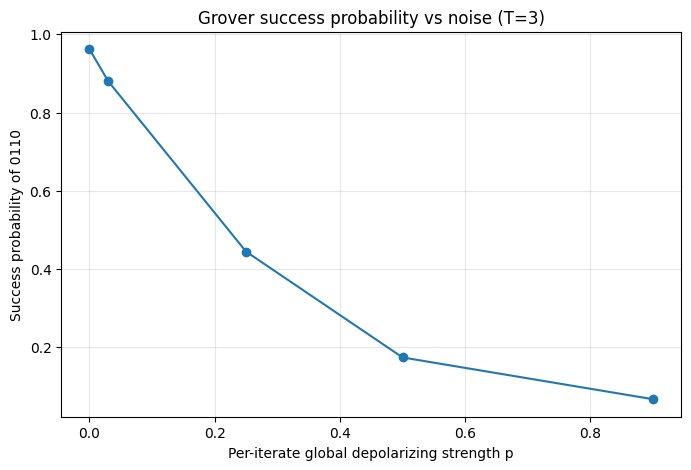

In [ ]:
# Plot success vs p

success_vals = []

for p in p_list:
    qc = build_grover_circuit_global_iterate_noise(num_iterations=T, p_iter=p)
    counts = run_counts_density_matrix(qc, shots=shots)
    success_vals.append(success_probability(counts, target=target_state))

plt.figure(figsize=(8, 5))
plt.plot(p_list, success_vals, marker='o')

plt.xlabel("Per-iterate global depolarizing strength p")
plt.ylabel(f"Success probability of {target_state}")
plt.title(f"Grover success probability vs noise (T={T})")
plt.grid(True, alpha=0.3)
plt.show()

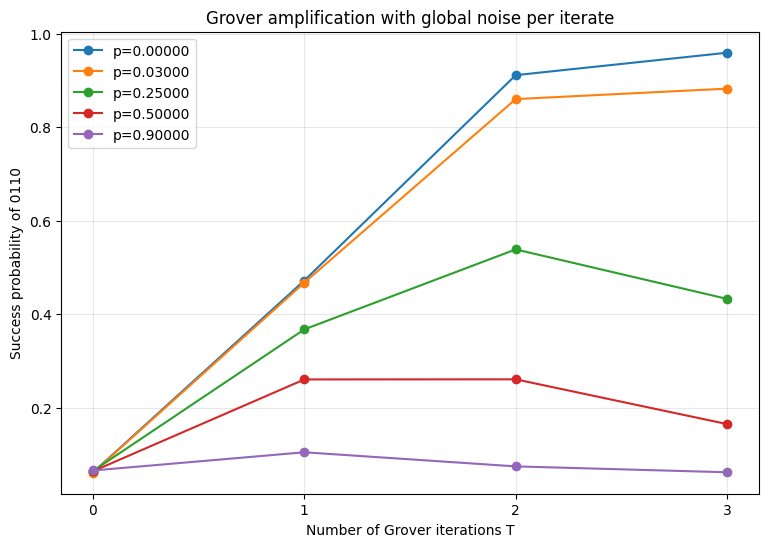

In [ ]:

# Amplification curves

iterations = range(0, 4)

plt.figure(figsize=(9, 6))

for p in p_list:
    probs = []
    for t in iterations:
        qc = build_grover_circuit_global_iterate_noise(num_iterations=t, p_iter=p)
        counts = run_counts_density_matrix(qc, shots=shots)
        probs.append(success_probability(counts, target=target_state))
    plt.plot(iterations, probs, marker='o', label=f"p={p:.5f}")

plt.xlabel("Number of Grover iterations T")
plt.ylabel(f"Success probability of {target_state}")
plt.title("Grover amplification with global noise per iterate")
plt.grid(True, alpha=0.3)
plt.legend()

plt.xticks(list(iterations))
plt.show()

## Summary of Results

From the analysis of Grover's algorithm under iterate-level global depolarizing noise, we observe the following:

1.  **Success Probability vs. Noise Strength ($p$):**
    -   As the per-iterate global depolarizing strength $p$ increases, the success probability of finding the target state ('0110') significantly decreases. For $T=3$ iterations, the success probability drops from approximately 96.4% at $p=0.0$ to about 6.3% at $p=0.9$. This demonstrates the detrimental effect of noise on the algorithm's performance.

2.  **Amplification Curves:**
    -   For $p=0$ (no noise), the success probability generally increases with the number of Grover iterations, showing the characteristic amplification effect of the algorithm, peaking at a certain optimal number of iterations.
    -   As $p$ increases, the amplification curves are suppressed. The peak success probability is lower, and it often occurs at fewer iterations or doesn't show a clear amplification beyond initial iterations. For high noise levels, the success probability remains low across all iterations, indicating that the noise overwhelms the amplification process, making it difficult to distinguish the target state from other states.